# Sistema Agéntico de Predicción - Premier League

## Orquestador del Pipeline Agéntico

Este notebook coordina la ejecución secuencial de tres skills complementarias para análisis predictivo de partidos de la Premier League:

1. **preparacion-datos** ➡️ Carga, limpieza y enriquecimiento de datos
2. **analisis-exploratorio** ➡️ EDA con análisis descriptivos y visualizaciones
3. **modelado-predictivo** ➡️ Entrenamiento y evaluación de modelos ML

El sistema sigue el estándar de **Anthropic Agent Skills** con una estructura modular donde cada skill es independiente pero forma parte de un pipeline coherente.

---

## Celda 1: Configuración Inicial del Agente

Cargar las herramientas necesarias y configurar el entorno de ejecución.

In [1]:
import subprocess
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from pathlib import Path

# Configurar visualización
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Definir la raíz del proyecto (subir un nivel desde notebooks/)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Ruta de la base de datos
db_path = os.path.join(project_root, 'data', 'premier_league.db')

print("="*70)
print("SISTEMA AGÉNTICO DE PREDICCIÓN - PREMIER LEAGUE")
print("="*70)
print(f"\n✓ Raíz del proyecto: {project_root}")
print(f"✓ Base de datos ubicada: {os.path.exists(db_path)}")
print(f"✓ Entorno configurado")
print(f"✓ Skills disponibles: 3 (preparacion, eda, modelado)")
print("\nEstándar: Anthropic Agent Skills Framework")

SISTEMA AGÉNTICO DE PREDICCIÓN - PREMIER LEAGUE

✓ Raíz del proyecto: c:\Users\juanc\Documents\Universidad\Programacion Analitica De Datos\ProyectoAgentico_BDFutbol
✓ Base de datos ubicada: True
✓ Entorno configurado
✓ Skills disponibles: 3 (preparacion, eda, modelado)

Estándar: Anthropic Agent Skills Framework


## Celda 2: Registro de Skills Disponibles

Mostrar la definición de cada skill desde sus archivos SKILL.md para confirmar que el agente conoce sus capacidades.

In [2]:
# Definir rutas de skills
skills_paths = {
    'preparacion-datos': os.path.join(project_root, 'skills', 'preparacion', 'SKILL.md'),
    'analisis-exploratorio': os.path.join(project_root, 'skills', 'eda', 'SKILL.md'),
    'modelado-predictivo': os.path.join(project_root, 'skills', 'modelado', 'SKILL.md')
}

print("\n" + "="*70)
print("REGISTRO DE SKILLS DEL AGENTE")
print("="*70)

for skill_name, skill_path in skills_paths.items():
    if os.path.exists(skill_path):
        with open(skill_path, 'r', encoding='utf-8') as f:
            contenido = f.read()
            # Extraer frontmatter YAML
            import re
            match = re.search(r'---\n(.*?)\n---', contenido, re.DOTALL)
            if match:
                frontmatter = match.group(1)
                print(f"\n✓ {skill_name}:")
                for line in frontmatter.split('\n'):
                    if line.strip():
                        print(f"  {line}")
    else:
        print(f"\n⚠ {skill_name}: No encontrado en {skill_path}")

        
print("\n" + "="*70)
print("Todas las skills están registradas y disponibles para ejecución")
print("="*70)


REGISTRO DE SKILLS DEL AGENTE

✓ preparacion-datos:
  name: preparacion-datos
  description: Carga datos de partidos de Premier League desde SQLite, limpia el dataset y calcula features históricas como promedio de goles y racha de victorias para preparar los datos para modelado predictivo.

✓ analisis-exploratorio:
  name: analisis-exploratorio
  description: Ejecuta análisis exploratorio sobre el dataset preparado de Premier League, genera estadísticas descriptivas, distribución de resultados, top equipos y visualizaciones guardadas como imágenes PNG.

✓ modelado-predictivo:
  name: modelado-predictivo
  description: Entrena LogisticRegression y RandomForestClassifier para predecir resultados de partidos (Local/Empate/Visitante), evalúa con accuracy/precision/recall, selecciona el mejor modelo y genera reporte.

Todas las skills están registradas y disponibles para ejecución


## Celda 3: Ejecutar Skill - Preparación de Datos

**Entrada**: `premier_league.db` (380 partidos)  
**Salida**: `data/dataset_preparado.csv` (con features históricas)

Esta skill es el primer paso del pipeline.

In [3]:
print("\n" + "="*70)
print("[SKILL 1/3] EJECUTANDO: preparacion-datos")
print("="*70)

# Definir ruta del script
script_preparacion = os.path.join(project_root, 'skills', 'preparacion', 'preparacion.py')

try:
    resultado = subprocess.run(
        ['python', script_preparacion, db_path],
        capture_output=True,
        text=True,
        timeout=300,
        cwd=project_root
    )
    
    print(resultado.stdout)
    
    if resultado.returncode != 0:
        print(f"❌ Error en ejecución:\n{resultado.stderr}")
    else:
        print("\n✅ SKILL 1 COMPLETADA EXITOSAMENTE")
        
except subprocess.TimeoutExpired:
    print("❌ Timeout: La ejecución tardó más de 5 minutos")
except Exception as e:
    print(f"❌ Error: {e}")


[SKILL 1/3] EJECUTANDO: preparacion-datos
INICIANDO PIPELINE DE PREPARACIÓN DE DATOS

[1/5] Cargando datos...

[2/5] Limpiando datos...
✓ Duplicados eliminados: 0
✓ Tipos de datos convertidos correctamente
✓ Datos ordenados por fecha. Rango: 2024-08-16 a 2025-05-25

[3/5] Creando features históricas...
Calculando features históricas...
  → Procesados 38/380 partidos...
  → Procesados 76/380 partidos...
  → Procesados 114/380 partidos...
  → Procesados 152/380 partidos...
  → Procesados 190/380 partidos...
  → Procesados 228/380 partidos...
  → Procesados 266/380 partidos...
  → Procesados 304/380 partidos...
  → Procesados 342/380 partidos...
  → Procesados 380/380 partidos...
✓ Features históricas calculadas para 380 partidos

[4/5] Creando variable objetivo...
✓ Variable objetivo 'resultado' creada:
  - Local: 155 (40.8%)
  - Visitante: 132 (34.7%)
  - Empate: 93 (24.5%)

[5/5] Generando resumen final...
----------------------------------------------------------------------
Dataset 

## Celda 4: Ejecutar Skill - Análisis Exploratorio

**Entrada**: `data/dataset_preparado.csv` (generado por skill anterior)  
**Salida**: 
- `data/reporte_eda.json` (hallazgos principales)
- `graphs/01_*.png`, `graphs/02_*.png`, `graphs/03_*.png` (visualizaciones)

Esta skill es el segundo paso del pipeline.

In [4]:
print("\n" + "="*70)
print("[SKILL 2/3] EJECUTANDO: analisis-exploratorio")
print("="*70)

# Definir ruta del script
script_eda = os.path.join(project_root, 'skills', 'eda', 'eda.py')

try:
    resultado = subprocess.run(
        ['python', script_eda],
        capture_output=True,
        text=True,
        timeout=300,
        cwd=project_root
    )
    
    print(resultado.stdout)
    
    if resultado.returncode != 0:
        print(f"❌ Error en ejecución:\n{resultado.stderr}")
    else:
        print("\n✅ SKILL 2 COMPLETADA EXITOSAMENTE")
        
except subprocess.TimeoutExpired:
    print("❌ Timeout: La ejecución tardó más de 5 minutos")
except Exception as e:
    print(f"❌ Error: {e}")


[SKILL 2/3] EJECUTANDO: analisis-exploratorio
INICIANDO ANÁLISIS EXPLORATORIO DE DATOS (EDA)

[1/6] Calculando estadísticas descriptivas...
📊 ESTADÍSTICAS DESCRIPTIVAS GENERALES
----------------------------------------------------------------------
Total de partidos: 380
Rango de fechas: 2024-08-16 a 2025-05-25
Cantidad de equipos únicos: 20
Promedio de goles por partido: 2.93
Promedio de goles local: 1.51
Promedio de goles visitante: 1.42

[2/6] Analizando distribución de resultados...
⚽ DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
----------------------------------------------------------------------
Local        :   155 partidos ( 40.8%)
Empate       :    93 partidos ( 24.5%)
Visitante    :   132 partidos ( 34.7%)

[3/6] Analizando equipos dominantes como local...
🏆 TOP 5 EQUIPOS CON MÁS VICTORIAS COMO LOCAL
----------------------------------------------------------------------
1. Liverpool            : 14 victorias de 19 locales ( 73.7%)
2. Manchester City      : 13 victorias de 19 locale

In [5]:
print("\n" + "="*70)
print("[SKILL 3/3] EJECUTANDO: modelado-predictivo")
print("="*70)

# Definir ruta del script
script_modelado = os.path.join(project_root, 'skills', 'modelado', 'modelado.py')

try:
    resultado = subprocess.run(
        ['python', script_modelado],
        capture_output=True,
        text=True,
        timeout=300,
        cwd=project_root
    )
    
    print(resultado.stdout)
    
    if resultado.returncode != 0:
        print(f"❌ Error en ejecución:\n{resultado.stderr}")
    else:
        print("\n✅ SKILL 3 COMPLETADA EXITOSAMENTE")
        
except subprocess.TimeoutExpired:
    print("❌ Timeout: La ejecución tardó más de 5 minutos")
except Exception as e:
    print(f"❌ Error: {e}")


[SKILL 3/3] EJECUTANDO: modelado-predictivo
INICIANDO PIPELINE DE MODELADO PREDICTIVO

[1/9] Preparando datos...
✓ Features seleccionados: ['promedio_goles_local', 'promedio_goles_visitante', 'racha_local', 'racha_visitante', 'ventaja_local']
✓ Dimensiones: X=(380, 5), y=(380,)
✓ Clases: ['Empate' 'Local' 'Visitante']

[2/9] Dividiendo datos en entrenamiento/prueba...
✓ Datos divididos:
  - Entrenamiento: 304 samples (80%)
  - Prueba: 76 samples (20%)

[3/9] Escalando features...
✓ Features escalados usando StandardScaler

[4/9] Entrenando LogisticRegression...
✓ Modelo LogisticRegression entrenado

[5/9] Entrenando RandomForestClassifier...
✓ Modelo RandomForestClassifier entrenado

[6/9] Evaluando LogisticRegression...

📊 MÉTRICAS - LogisticRegression
----------------------------------------------------------------------
Accuracy:  0.5132
Precision: 0.3519
Recall:    0.4462

[7/9] Evaluando RandomForestClassifier...

📊 MÉTRICAS - RandomForestClassifier
------------------------------

In [6]:
print("\n" + "="*70)
print("CELDA 6: RESULTADOS FINALES DEL SISTEMA AGÉNTICO")
print("="*70)

# Ruta al reporte
reporte_path = os.path.join(project_root, 'data', 'reporte_modelado.json')

# Cargar reporte de modelado
if os.path.exists(reporte_path):
    with open(reporte_path, 'r', encoding='utf-8') as f:
        reporte = json.load(f)
    
    print(f"\n🏆 MODELO GANADOR: {reporte['mejor_modelo']}")
    print("-"*70)
    
    print(f"\n📊 MÉTRICAS DE DESEMPEÑO:")
    print(f"  - Accuracy:  {reporte['metricas']['accuracy']:.4f} ({reporte['metricas']['accuracy']*100:.2f}%)")
    print(f"  - Precision: {reporte['metricas']['precision']:.4f}")
    print(f"  - Recall:    {reporte['metricas']['recall']:.4f}")
    
    print(f"\n📋 ANÁLISIS DETALLADO:")
    for clave, contenido in reporte['reporte_modelado'].items():
        print(f"\n{clave.upper().replace('_', ' ')}:")
        print(f"{contenido}")
        
    print("\n" + "="*70)
else:
    print(f"\n⚠ Reporte de modelado no encontrado en: {reporte_path}")


CELDA 6: RESULTADOS FINALES DEL SISTEMA AGÉNTICO

🏆 MODELO GANADOR: LogisticRegression
----------------------------------------------------------------------

📊 MÉTRICAS DE DESEMPEÑO:
  - Accuracy:  0.5132 (51.32%)
  - Precision: 0.3519
  - Recall:    0.4462

📋 ANÁLISIS DETALLADO:

RENDIMIENTO GENERAL:
Se entrenaron dos modelos: LogisticRegression (Accuracy: 0.5132) y RandomForestClassifier (Accuracy: 0.4868). El modelo ganador es LogisticRegression con una precisión del 51.32%.

METRICAS DETALLADAS:
El modelo ganador (LogisticRegression) presenta:
- Accuracy (precisión general): 0.5132
- Precision (macro): 0.3519
- Recall (macro): 0.4462
Estas métricas indican un rendimiento equilibrado en la predicción de los tres resultados.

JUSTIFICACION:
LogisticRegression demostró un rendimiento superior, sugiriendo que las relaciones entre las features y el resultado son predominantemente lineales. Su simplicidad también facilita la interpretabilidad del modelo.

RECOMENDACIONES:
Se recomienda

## Celda 7: Visualizaciones Generadas

Mostrar todas las gráficas generadas por las skills del análisis exploratorio y modelado.

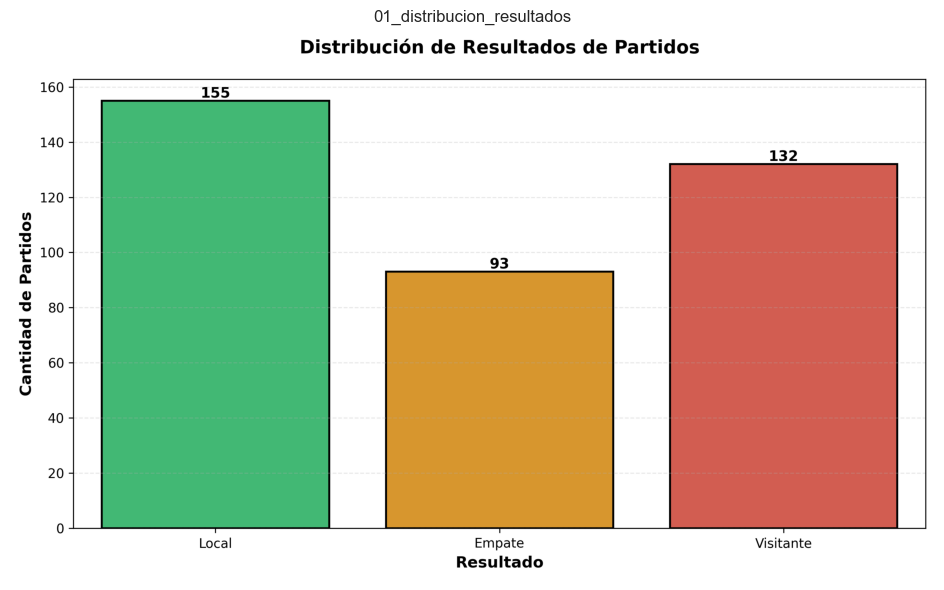

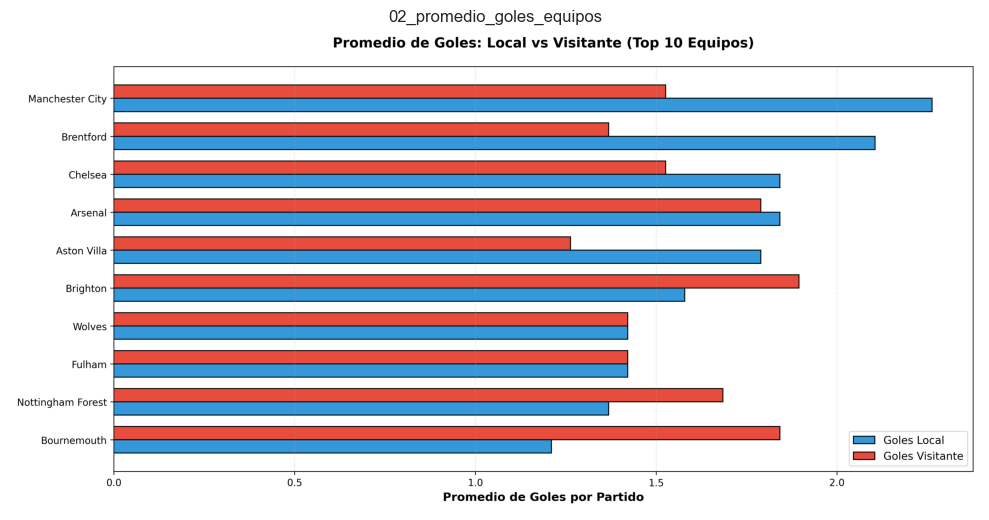

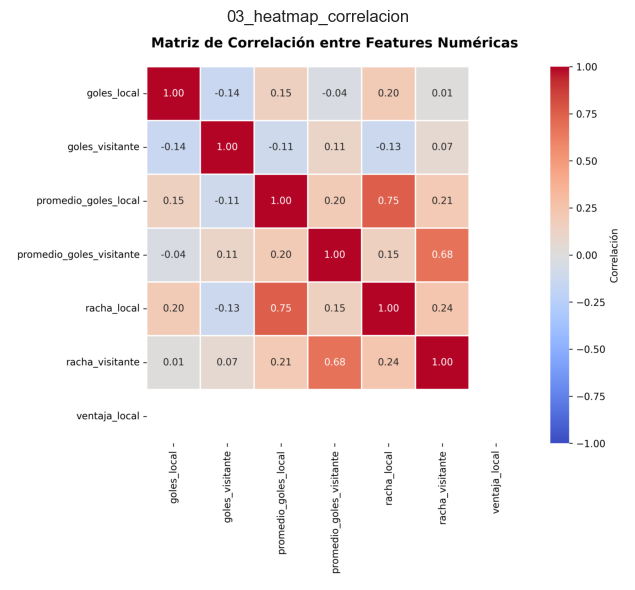

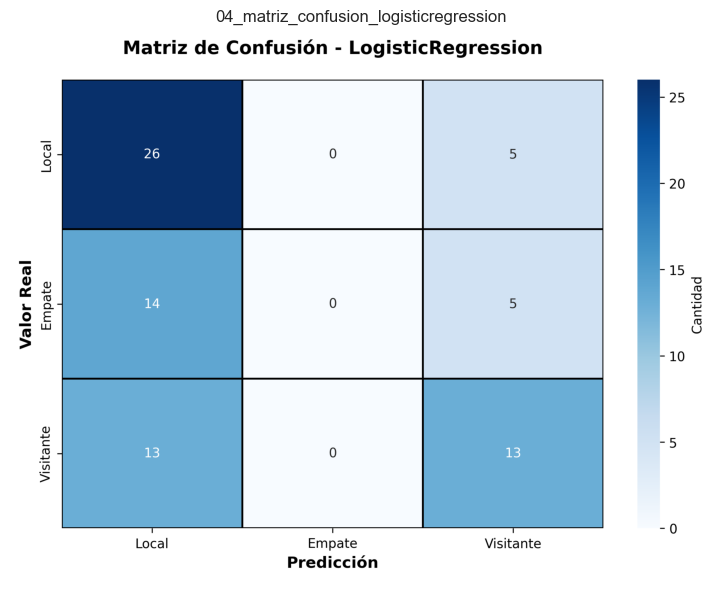

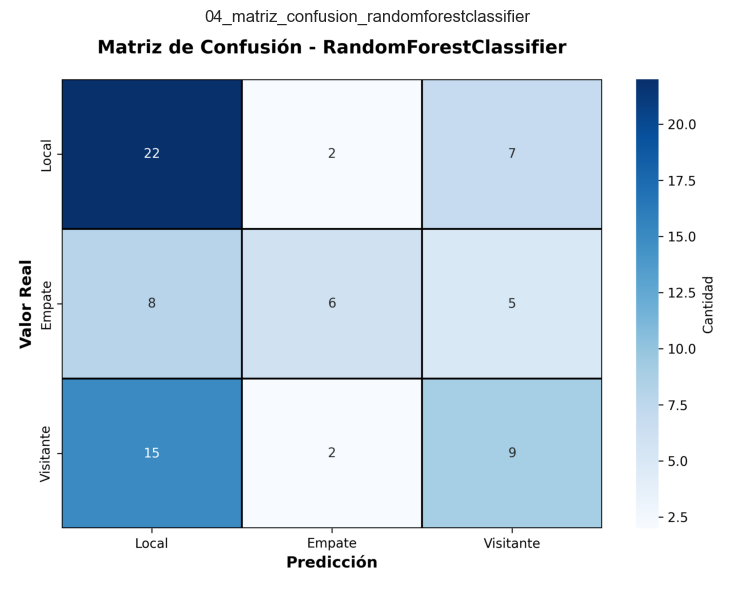

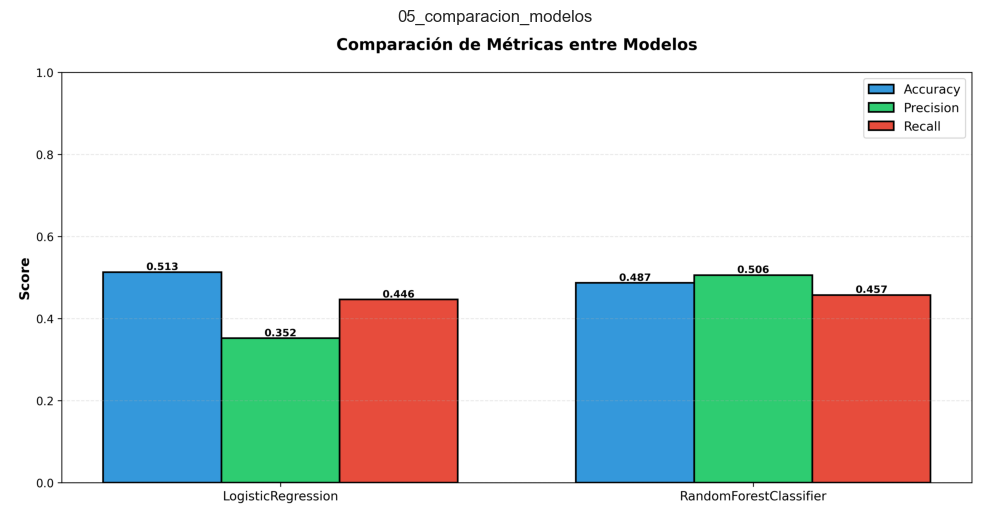

In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
graphs_path = os.path.join(project_root, 'data', 'graphs')

graficas = [
    '01_distribucion_resultados.png',
    '02_promedio_goles_equipos.png', 
    '03_heatmap_correlacion.png',
    '04_matriz_confusion_logisticregression.png',
    '04_matriz_confusion_randomforestclassifier.png',
    '05_comparacion_modelos.png'
]

for nombre in graficas:
    ruta = os.path.join(graphs_path, nombre)
    if os.path.exists(ruta):
        fig, ax = plt.subplots(figsize=(10, 6))
        img = mpimg.imread(ruta)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(nombre.replace('.png', ''))
        plt.tight_layout()
        plt.show()
    else:
        print(f'No encontrado: {ruta}')